# LangGraph Multi-Agent Patterns

This notebook contains eight independent multi-agent patterns. Run the setup cells first, then study and test one pattern at a time. Tests are placed directly after their examples.


## Pattern Comparison

| # | Pattern | Main control style | Typical model calls in this test |
|---:|---|---|---:|
| 1 | Router | Select one specialist | 2 |
| 2 | Subagents / Agent-as-Tool | Main agent delegates through tools | Variable |
| 3 | Supervisor | Supervisor repeatedly selects workers | Variable, bounded |
| 4 | Handoff | Triage transfers control to one specialist | 2 |
| 5 | Swarm | Agents hand control to one another | Variable |
| 6 | Hierarchical Supervisor | Top supervisor selects a team subgraph | 3 |
| 7 | Parallel Collaboration with `Send` | Dynamic fan-out and aggregation | `N + 2` |
| 8 | Coordinator-Guided Peer Network | Coordinator repeatedly selects a peer | Variable, bounded |

> The examples are independent. Running every test will make many API calls, so run one pattern at a time while teaching.


## Setup

The Swarm example requires `langgraph-swarm`. In this project environment it is installed as version `0.1.0`. The API key is loaded from the project `.env` file.


In [1]:
from typing import (
    TypedDict,
    Literal,
    Annotated,
)

import operator

from dotenv import load_dotenv
from pydantic import BaseModel

from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
)
from langchain_core.tools import tool
from langchain.agents import create_agent

from langgraph.graph import (
    StateGraph,
    START,
    END,
    MessagesState,
)
from langgraph.types import (
    Command,
    Send,
)
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
)

In [4]:
def print_title(title: str):
    print("\n")
    print("=" * 80)
    print(title)
    print("=" * 80)

In [5]:
def show_graph(compiled_graph):
    """Print the generated graph as Mermaid text."""
    print(compiled_graph.get_graph().draw_mermaid())

## 1. Router Multi-Agent

**How it works:** A router reads the request and selects exactly one specialist. Only that specialist answers.

**Real-world example:** A customer-support desk sends a duplicate payment issue to billing, a login issue to technical support, and a general question to general support.

```text
User → Router → One Specialist → Response
```


### State and routing schema


In [7]:
class RouterDecision(BaseModel):
    route: Literal[
        "technical",
        "billing",
        "general",
    ]

In [8]:
router_model = model.with_structured_output(RouterDecision)

In [9]:
router_model.invoke("can you resolve the bug in my system?")

RouterDecision(route='technical')

In [10]:
class RouterState(TypedDict):
    query: str
    route: str
    response: str

### Router and specialist nodes


In [11]:
def router_node(state: RouterState,):

    decision = router_model.invoke(
        f"""
Route the following user query to exactly one specialist.

Available specialists:
- technical
- billing
- general

User query:
{state["query"]}
"""
    )

    return {
        "route": decision.route
    }

In [12]:
def technical_agent(state: RouterState):
    response = model.invoke(
        f"""
You are a technical support specialist.

Answer this query:
{state["query"]}
"""
    )

    return {
        "response": response.content
    }

In [13]:
def billing_agent(state: RouterState,):

    response = model.invoke(
        f"""
You are a billing support specialist.

Answer this query:
{state["query"]}
"""
    )

    return {
        "response": response.content
    }


In [14]:
def general_agent(state: RouterState,):

    response = model.invoke(
        f"""
You are a general support specialist.

Answer this query:
{state["query"]}
"""
    )

    return {
        "response": response.content
    }

In [16]:
def route_to_specialist(state: RouterState,):
    return state["route"]


### Build the graph


In [17]:
def build_router_multi_agent():
    builder = StateGraph(RouterState)
    
    builder.add_node(
        "router",
        router_node,
    )

    builder.add_node(
        "technical",
        technical_agent,
    )

    builder.add_node(
        "billing",
        billing_agent,
    )

    builder.add_node(
        "general",
        general_agent,
    )

    builder.add_edge(
        START,
        "router",
    )

    builder.add_conditional_edges(
        "router",
        route_to_specialist,
        {
            "technical": "technical",
            "billing": "billing",
            "general": "general",
        },
    )

    builder.add_edge(
        "technical",
        END,
    )

    builder.add_edge(
        "billing",
        END,
    )

    builder.add_edge(
        "general",
        END,
    )

    return builder.compile()


### Generated graph structure

This cell builds the graph and prints its Mermaid definition without invoking the model.


In [19]:
router_graph = build_router_multi_agent()

In [20]:
show_graph(router_graph)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	technical(technical)
	billing(billing)
	general(general)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	router -.-> billing;
	router -.-> general;
	router -.-> technical;
	billing --> __end__;
	general --> __end__;
	technical --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



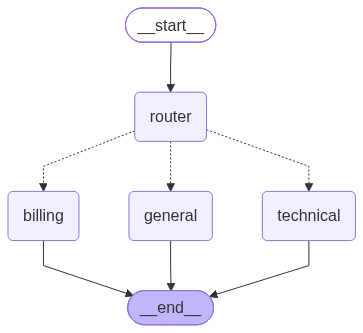

In [21]:
router_graph

better terminology:
“This is a router-based LLM workflow with specialized LLM nodes.”

Not a full multi-agent system in the strict sense.

If technical_agent does something like this:
Technical Agent
   ↓
Decides:
Do I need documentation search?
   ↓
Calls search tool
   ↓
Checks result
   ↓
Maybe calls another tool
   ↓
Decides when to stop

then calling it a proper agent is more justified.

Simple distinction:

Your current code:

LLM Router
   ↓
Fixed specialist node
   ↓
LLM response

= Routing Workflow

Proper agent version:
LLM Router
   ↓
Technical Agent
   ↓
LLM decides action
   ├── Search tool
   ├── API tool
   ├── Database tool
   └── Final answer
        ↺

In class, you can say:
“Although we may name these nodes technical agent or billing agent, in this implementation they are specialized LLM nodes rather than fully autonomous agents. The overall architecture is primarily a routing workflow.”

And remember this line:
Role ≠ Agent. Autonomy and action-selection make it agentic.

##### This is a router-based LLM workflow with specialized LLM nodes.

### Test

**Expected behavior:** The duplicate-charge query is routed to `billing`, and the billing specialist produces the response.

**Model calls:** 2.


In [22]:
def run_router_multi_agent():

    print_title(
        "1. ROUTER MULTI-AGENT"
    )

    graph = (build_router_multi_agent())

    result = graph.invoke(
        {
            "query":"My subscription payment was charged twice.",
            "route": "",
            "response": "",
        }
    )

    print(
        "Selected Agent:",
        result["route"],
    )

    print(
        "\nResponse:\n",
        result["response"],
    )

    return result


In [23]:
router_result = run_router_multi_agent()




1. ROUTER MULTI-AGENT
Selected Agent: billing

Response:
 I'm sorry to hear that your subscription payment was charged twice. To assist you better, could you please provide the following details?

1. Your account email or username  
2. The date of the charges  
3. The amount charged  

Once I have this information, I can investigate the issue and help process a refund if necessary.


## 2. Subagents / Agent-as-Tool

**How it works:** A main coordinator remains in control and calls specialist agents as tools. Each specialist has a focused role.

**Real-world example:** A consultant asks a researcher for facts, a math expert for a calculation, and a writer to present the combined answer clearly.

```text
User → Main Agent → Specialist Tools → Main Agent → Final Answer
```


### Create the specialist subagents


In [21]:
research_subagent = create_agent(
    model=model,
    tools=[],
    system_prompt=(
        "You are a research specialist. "
        "Provide concise factual research."
    ),
    name="research_subagent",
)

In [22]:
math_subagent = create_agent(
    model=model,
    tools=[],
    system_prompt=(
        "You are a math specialist. "
        "Solve calculations accurately."
    ),
    name="math_subagent",
)

In [23]:
writing_subagent = create_agent(
    model=model,
    tools=[],
    system_prompt=(
        "You are a professional writing specialist. "
        "Rewrite information clearly and concisely."
    ),
    name="writing_subagent",
)

### Wrap subagents as tools and create the coordinator


In [24]:
def get_last_message_content(
    result,
):

    return (
        result["messages"][-1].content
    )


In [25]:
@tool
def ask_research_agent(
    task: str,
) -> str:
    """
    Delegate a research task to the research specialist.
    """

    result = research_subagent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": task,
                }
            ]
        }
    )

    return get_last_message_content(
        result
    )

In [26]:
@tool
def ask_math_agent(
    task: str,
) -> str:
    """
    Delegate a mathematical task to the math specialist.
    """

    result = math_subagent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": task,
                }
            ]
        }
    )

    return get_last_message_content(
        result
    )

In [27]:
@tool
def ask_writing_agent(
    task: str,
) -> str:
    """
    Delegate a writing task to the writing specialist.
    """

    result = writing_subagent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": task,
                }
            ]
        }
    )

    return get_last_message_content(
        result
    )

In [28]:
main_delegation_agent = create_agent(
    model=model,
    tools=[
        ask_research_agent,
        ask_math_agent,
        ask_writing_agent,
    ],
    system_prompt="""
You are the main coordinator.

You have three specialist subagents:
1. Research specialist
2. Math specialist
3. Writing specialist

Delegate work to the appropriate specialist tools.
You may call multiple specialists when necessary.
Finally provide one clear answer to the user.
""",
    name="main_coordinator",
)


### Generated graph structure

This cell builds the graph and prints its Mermaid definition without invoking the model.


In [29]:
show_graph(main_delegation_agent)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model(model)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> model;
	model -.-> __end__;
	model -.-> tools;
	tools -.-> model;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



                    Main Coordinator Agent
                            |
               LLM decides which tool to call
                            |
          ┌─────────────────┼─────────────────┐
          ↓                 ↓                 ↓
 ask_research_agent   ask_math_agent   ask_writing_agent
          ↓                 ↓                 ↓
 Research Subagent     Math Subagent     Writing Subagent

“This is a subagent-as-tool multi-agent architecture where a coordinator agent dynamically delegates tasks to specialized subagents.”

Aur exact distinction:
Main Coordinator
= Proper agent
  because it dynamically selects tools/subagents.

Research / Math / Writing subagents
= Specialized agent/worker objects,
  but currently they have no tools,
  so their behavior is essentially specialized LLM generation.

Previous router example:
Router
  ↓
technical node
  ↓
END

= Routing workflow

Current example:
Coordinator Agent
   ↓
decides which subagent tool to call
   ↓
Subagent
   ↓
result comes back
   ↓
Coordinator can call another subagent
   ↓
Final answer

= Multi-agent / subagent delegation pattern

“In this architecture, the coordinator is clearly agentic because it dynamically decides which subagent to invoke. The specialist subagents are created as agents, but since they currently have no tools, they behave mainly as specialized LLM workers.”

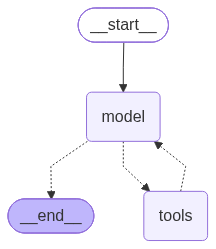

In [30]:
main_delegation_agent

### Test

**Expected behavior:** The coordinator may delegate research, multiplication, and writing before returning one answer.

**Model calls:** Variable because the main agent decides which tools to call.


In [31]:
def run_subagents():

    print_title(
        "2. SUBAGENTS / AGENT-AS-TOOL"
    )

    result = (
        main_delegation_agent.invoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Explain RAG briefly, calculate "
                            "25 * 16, and present the answer "
                            "in a clean professional format."
                        ),
                    }
                ]
            }
        )
    )

    print(
        result["messages"][-1].content
    )

    return result


In [32]:
subagents_result = run_subagents()




2. SUBAGENTS / AGENT-AS-TOOL
**Retrieval-Augmented Generation (RAG)**

Retrieval-Augmented Generation (RAG) is an advanced natural language processing technique that combines retrieval-based methods with generative models. It enhances the generation of accurate and contextually relevant responses by first retrieving pertinent information from a large external knowledge base and then using this information to guide the generation process. This approach improves the quality and factual correctness of the output, making it particularly useful in applications such as question answering and knowledge-intensive tasks.

---

**Calculation: 25 × 16**

To calculate 25 multiplied by 16:

- Break down 16 into 10 and 6.
- Multiply 25 by 10: 25 × 10 = 250.
- Multiply 25 by 6: 25 × 6 = 150.
- Add the two results: 250 + 150 = 400.

**Result:** 25 × 16 = 400


## 3. Supervisor Multi-Agent

**How it works:** A central supervisor repeatedly selects the next worker, reviews accumulated work, and finishes when enough work is available. A six-turn limit prevents an endless loop.

**Real-world example:** A project manager assigns research, calculation, and writing tasks one at a time, then creates the final training note.

```text
Supervisor → Worker → Supervisor → Another Worker → Finish
```


### State and supervisor decision schema


In [33]:
class SupervisorDecision(BaseModel):

    next_agent: Literal[
        "research_agent",
        "math_agent",
        "writer_agent",
        "FINISH",
    ]

    instruction: str

In [34]:
class SupervisorState(TypedDict):

    task: str

    next_agent: str

    instruction: str

    worker_outputs: Annotated[
        list[str],
        operator.add,
    ]

    final_answer: str

    supervisor_turns: int

In [35]:
supervisor_router = (
    model.with_structured_output(
        SupervisorDecision
    )
)

### Supervisor and worker nodes


In [36]:
def supervisor(
    state: SupervisorState,
):

    supervisor_turns = state.get(
        "supervisor_turns",
        0,
    ) + 1

    completed_work = "\n\n".join(
        state.get(
            "worker_outputs",
            [],
        )
    )

    if supervisor_turns >= 6 and completed_work:
        return {
            "next_agent": "FINISH",
            "instruction": (
                "Maximum supervisor turns reached. "
                "Create the final answer."
            ),
            "supervisor_turns": supervisor_turns,
        }

    decision = supervisor_router.invoke(
        f"""
You are a supervisor managing three workers:

- research_agent
- math_agent
- writer_agent

Original task:
{state["task"]}

Work completed so far:
{completed_work or "No worker has completed any work yet."}

Choose the next worker.

Rules:
- Use research_agent for research/explanation.
- Use math_agent for calculations.
- Use writer_agent when a polished final presentation is useful.
- If enough work is complete, choose FINISH.
- Do not repeatedly call the same worker unless required.

Return:
- next_agent
- instruction for that worker
"""
    )

    return {
        "next_agent":
        decision.next_agent,

        "instruction":
        decision.instruction,

        "supervisor_turns":
        supervisor_turns,
    }


In [37]:
def supervisor_research_worker(
    state: SupervisorState,
):

    response = model.invoke(
        f"""
You are the research worker.

Original task:
{state["task"]}

Supervisor instruction:
{state["instruction"]}

Perform only the research/explanation part.
"""
    )

    return {
        "worker_outputs": [
            "RESEARCH WORKER:\n"
            + response.content
        ]
    }

In [38]:
def supervisor_math_worker(
    state: SupervisorState,
):

    response = model.invoke(
        f"""
You are the math worker.

Original task:
{state["task"]}

Supervisor instruction:
{state["instruction"]}

Perform only the calculation/reasoning part.
"""
    )

    return {
        "worker_outputs": [
            "MATH WORKER:\n"
            + response.content
        ]
    }



In [39]:


def supervisor_writer_worker(
    state: SupervisorState,
):

    previous_work = "\n\n".join(
        state.get(
            "worker_outputs",
            [],
        )
    )

    response = model.invoke(
        f"""
You are the writing worker.

Original task:
{state["task"]}

Supervisor instruction:
{state["instruction"]}

Available previous work:
{previous_work}

Create a polished response or writing contribution.
"""
    )

    return {
        "worker_outputs": [
            "WRITER WORKER:\n"
            + response.content
        ]
    }

In [40]:
def supervisor_finish(
    state: SupervisorState,
):

    completed_work = "\n\n".join(
        state["worker_outputs"]
    )

    response = model.invoke(
        f"""
You are the supervisor.

Create the final answer for the user.

Original task:
{state["task"]}

Worker outputs:
{completed_work}
"""
    )

    return {
        "final_answer":
        response.content
    }

In [41]:
def supervisor_route(
    state: SupervisorState,
):

    return state["next_agent"]

### Build the graph


In [42]:
def build_supervisor_graph():

    builder = StateGraph(
        SupervisorState
    )

    builder.add_node(
        "supervisor",
        supervisor,
    )

    builder.add_node(
        "research_agent",
        supervisor_research_worker,
    )

    builder.add_node(
        "math_agent",
        supervisor_math_worker,
    )

    builder.add_node(
        "writer_agent",
        supervisor_writer_worker,
    )

    builder.add_node(
        "finish",
        supervisor_finish,
    )

    builder.add_edge(
        START,
        "supervisor",
    )

    builder.add_conditional_edges(
        "supervisor",
        supervisor_route,
        {
            "research_agent":
            "research_agent",

            "math_agent":
            "math_agent",

            "writer_agent":
            "writer_agent",

            "FINISH":
            "finish",
        },
    )

    builder.add_edge(
        "research_agent",
        "supervisor",
    )

    builder.add_edge(
        "math_agent",
        "supervisor",
    )

    builder.add_edge(
        "writer_agent",
        "supervisor",
    )

    builder.add_edge(
        "finish",
        END,
    )

    return builder.compile()


### Generated graph structure

This cell builds the graph and prints its Mermaid definition without invoking the model.


In [43]:
supervisor_graph = build_supervisor_graph()
show_graph(supervisor_graph)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	research_agent(research_agent)
	math_agent(math_agent)
	writer_agent(writer_agent)
	finish(finish)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	math_agent --> supervisor;
	research_agent --> supervisor;
	supervisor -. &nbsp;FINISH&nbsp; .-> finish;
	supervisor -.-> math_agent;
	supervisor -.-> research_agent;
	supervisor -.-> writer_agent;
	writer_agent --> supervisor;
	finish --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



“This is a supervisor-based agentic workflow where the supervisor dynamically delegates tasks to specialized LLM workers.”
The supervisor is clearly agentic because:
LLM
↓
observes state
↓
decides the next action
↓
routes dynamically
↓
checks new results
↓
decides again

The workers are not fully autonomous agents yet.
If the workers also have tools:
Research Agent
   ↓
Search Web?
Search DB?
Call API?
   ↓
Observe
   ↓
Maybe call another tool
   ↓
Return result

then it becomes a much stronger multi-agent system.
Current flow
START
  ↓
Supervisor
  ↓
Choose worker
  ↓
Worker
  ↓
Supervisor
  ↓
Choose another worker
  ↓
Worker
  ↓
Supervisor
  ↓
FINISH
  ↓
Final Answer
  ↓
END

And this:
if supervisor_turns >= 6:


is just a safety guard.
If the supervisor keeps looping even after 6 turns, we force it to FINISH.

Best class line:
“In the supervisor pattern, a central LLM supervisor dynamically decides which specialized worker should execute next based on the task and the work completed so far. The workers return their outputs to the supervisor, and this loop continues until the supervisor decides to finish.”

For your current code:
Supervisor = agentic controller
Research / Math / Writer = specialized LLM workers

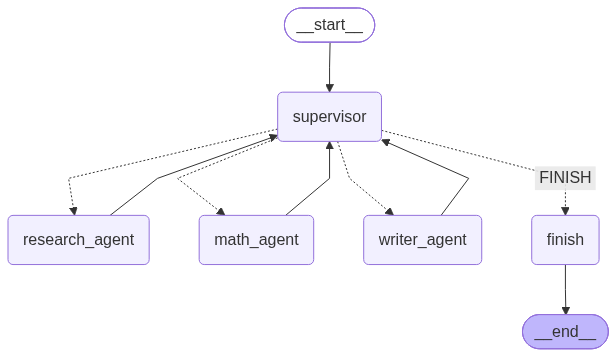

In [44]:
supervisor_graph

### Test

**Expected behavior:** The supervisor chooses useful workers and eventually returns a final training note. `supervisor_turns` cannot exceed the safety limit.

**Model calls:** Variable and bounded by the supervisor-turn limit.


In [45]:
def run_supervisor():

    print_title(
        "3. SUPERVISOR MULTI-AGENT"
    )

    graph = build_supervisor_graph()

    result = graph.invoke(
        {
            "task": (
                "Explain Retrieval-Augmented Generation, "
                "calculate 48 * 25, and present everything "
                "as a short training note."
            ),

            "next_agent": "",
            "instruction": "",
            "worker_outputs": [],
            "final_answer": "",
            "supervisor_turns": 0,
        },

        config={
            "recursion_limit": 20
        },
    )

    print(
        result["final_answer"]
    )

    return result


In [46]:
supervisor_result = run_supervisor()




3. SUPERVISOR MULTI-AGENT
**Training Note: Retrieval-Augmented Generation (RAG) and Practical Calculation**

Retrieval-Augmented Generation (RAG) is a technique in natural language processing that improves text generation by combining two components: retrieval and generation. Instead of relying solely on a language model’s internal knowledge, RAG first retrieves relevant documents or information from an external knowledge base based on the input query. This retrieved information then provides additional context for the generative model, enabling it to produce more accurate, informed, and contextually relevant responses.

**Key Features of RAG:**
- **Retrieval:** Searches a large database or corpus to find relevant passages related to the query.
- **Generation:** Produces text conditioned on both the input and the retrieved information.
- **Benefits:** Enhances factual accuracy, reduces hallucinations, and allows access to up-to-date or domain-specific knowledge without retraining.
- 

## 4. Handoff Multi-Agent

**How it works:** The triage agent selects a specialist and uses `Command(goto=...)` to transfer graph control. The selected specialist completes the request.

**Real-world example:** A reception desk transfers a 401 API error to technical support rather than trying to solve it itself.

```text
User → Triage ─┬→ Billing → END
               └→ Technical → END
```


### State and handoff decision schema


In [47]:
class HandoffDecision(BaseModel):

    target: Literal[
        "billing_agent",
        "technical_agent",
    ]

    reason: str


handoff_router_model = (
    model.with_structured_output(
        HandoffDecision
    )
)

In [48]:
class HandoffState(MessagesState):
    active_agent: str

### Triage and specialist nodes


In [49]:
def triage_handoff_agent(
    state: HandoffState,
) -> Command[
    Literal[
        "billing_agent",
        "technical_agent",
    ]
]:

    latest_user_message = (
        state["messages"][-1].content
    )

    decision = (
        handoff_router_model.invoke(
            f"""
You are a triage agent.

Choose which specialist should handle this user request.

billing_agent:
Payments, invoices, refunds, subscriptions.

technical_agent:
Software errors, login problems, API issues, technical troubleshooting.

User request:
{latest_user_message}
"""
        )
    )

    return Command(
        goto=decision.target,

        update={
            "active_agent":
            decision.target,

            "messages": [
                AIMessage(
                    content=(
                        "Handoff reason: "
                        + decision.reason
                    )
                )
            ],
        },
    )

In [50]:

def handoff_billing_agent(
    state: HandoffState,
):

    response = model.invoke(
        [
            {
                "role": "system",
                "content":
                "You are a billing support specialist.",
            },

            *state["messages"],
        ]
    )

    return {
        "messages": [
            response
        ],

        "active_agent":
        "billing_agent",
    }


In [51]:
def handoff_technical_agent(
    state: HandoffState,
):

    response = model.invoke(
        [
            {
                "role": "system",
                "content":
                "You are a technical support specialist.",
            },

            *state["messages"],
        ]
    )

    return {
        "messages": [
            response
        ],

        "active_agent":
        "technical_agent",
    }

### Build the graph


In [52]:
def build_handoff_graph():

    builder = StateGraph(
        HandoffState
    )

    builder.add_node(
        "triage",
        triage_handoff_agent,
    )

    builder.add_node(
        "billing_agent",
        handoff_billing_agent,
    )

    builder.add_node(
        "technical_agent",
        handoff_technical_agent,
    )

    builder.add_edge(
        START,
        "triage",
    )

    builder.add_edge(
        "billing_agent",
        END,
    )

    builder.add_edge(
        "technical_agent",
        END,
    )

    return builder.compile()


### Generated graph structure

This cell builds the graph and prints its Mermaid definition without invoking the model.


Full flow
START
  ↓
Triage
  ↓
LLM decides target
  ↓
Command(
   goto = selected specialist
)
  ↓
   ┌─────────────────────────┐
   │                         │
Billing Specialist    Technical Specialist
   │                         │
   └───────────┬─────────────┘
               ↓
              END

Router vs Handoff
This difference is important.
Normal routing:
Router
  ↓
Conditional Edge
  ↓
Specialist

Handoff:
Triage Agent
  ↓
Command(goto=...)
  ↓
Control transferred to specialist

The conceptual meaning of a handoff is:
“I have handled the request up to this point; now another specialist should take control.”

Is this multi-agent?
The best way to describe your current implementation is:
“This is a handoff-based agentic workflow where a triage LLM dynamically transfers control to a specialized LLM worker.”

Because:
Triage
= agentic controller / decision maker

Billing / Technical
= specialized LLM workers

If the billing and technical specialists also have tools and their own independent decision loops:
Technical Agent
    ↓
Search docs?
Call API?
Check logs?
    ↓
Observe result
    ↓
Maybe another tool
    ↓
Final answer

then it becomes a much stronger handoff-based multi-agent system.

“In the handoff pattern, one agent dynamically transfers control to another specialized agent or worker. In LangGraph, Command(goto=...) can be used to perform this handoff while also updating the shared graph state.”

Triage means examining an incoming request and routing it to the most appropriate specialist

In [53]:
handoff_graph = build_handoff_graph()
show_graph(handoff_graph)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	triage(triage)
	billing_agent(billing_agent)
	technical_agent(technical_agent)
	__end__([<p>__end__</p>]):::last
	__start__ --> triage;
	triage -.-> billing_agent;
	triage -.-> technical_agent;
	billing_agent --> __end__;
	technical_agent --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



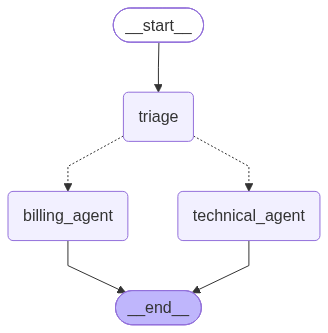

In [54]:
handoff_graph

### Test

**Expected behavior:** The 401 authentication problem is handed to `technical_agent`, which writes the final response.

**Model calls:** 2.


In [55]:
def run_handoffs():

    print_title(
        "4. HANDOFF MULTI-AGENT"
    )

    graph = build_handoff_graph()

    result = graph.invoke(
        {
            "messages": [
                HumanMessage(
                    content=(
                        "My API keeps returning "
                        "a 401 authentication error."
                    )
                )
            ],

            "active_agent":
            "triage",
        }
    )

    print(
        "Active Agent:",
        result["active_agent"],
    )

    print(
        "\nFinal Response:\n",
        result["messages"][-1].content,
    )

    return result


In [56]:
handoff_result = run_handoffs()




4. HANDOFF MULTI-AGENT
Active Agent: technical_agent

Final Response:
 A 401 authentication error typically means that your request is missing valid authentication credentials or the credentials provided are incorrect. Here are some steps to troubleshoot this issue:

1. **Check your API key or token:**  
   Ensure that you are including the correct API key, token, or credentials in your request headers or parameters as required by the API documentation.

2. **Verify the authentication method:**  
   Confirm whether the API requires Basic Auth, Bearer tokens, OAuth, or another method, and make sure you are implementing it correctly.

3. **Check for expired or revoked credentials:**  
   If you are using tokens, verify that they have not expired or been revoked. You may need to refresh or regenerate them.

4. **Review the request headers:**  
   Make sure the `Authorization` header is correctly formatted. For example, for a Bearer token, it should look like:  
   `Authorization: Bearer

## 5. Swarm Multi-Agent

**How it works:** Agents can hand control directly to another agent. `InMemorySaver` preserves the active-agent state for the thread.

**Real-world example:** A math expert calculates a result and hands it to a writer for professional presentation.

```text
Math Agent ⇄ Writer Agent
```


Full flow
START
  ↓
Math Agent
  ↓
LLM decides:
Can I handle this?
  │
  ├── Yes → answer
  │
  └── Need writing
          ↓
      Handoff Tool
          ↓
      Writer Agent
          ↓
      LLM decides:
      Need math?
          │
          ├── No → final response
          │
          └── Yes
                ↓
            Handoff Tool
                ↓
            Math Agent

Why is this more clearly multi-agent?
Because both agents are actual agents with tools:
Math Agent
→ has handoff tool
→ dynamically decides whether to use it

Writer Agent
→ has handoff tool
→ dynamically decides whether to use it

So unlike a simple routing workflow, the agents themselves decide when control should move.

“A swarm is a decentralized multi-agent architecture where agents can directly hand off control to one another based on the task, without requiring a permanent central supervisor.”

And the simple difference:
Supervisor pattern
→ one central supervisor decides everything

Swarm pattern
→ agents directly hand off control to each other

### Build the Swarm


In [57]:
def build_swarm_graph():

    # Optional dependency imported here
    # so the rest of the file can still
    # be studied without langgraph-swarm.

    from langgraph_swarm import (
        create_handoff_tool,
        create_swarm,
    )

    math_agent = create_agent(
        model=model,

        tools=[
            create_handoff_tool(
                agent_name="writer_agent",
                description=(
                    "Transfer to the writer "
                    "when polished writing is needed."
                ),
            )
        ],

        system_prompt=(
            "You are a math specialist. "
            "Solve calculations. "
            "Transfer to writer_agent when "
            "the result should be professionally presented."
        ),

        name="math_agent",
    )

    writer_agent = create_agent(
        model=model,

        tools=[
            create_handoff_tool(
                agent_name="math_agent",
                description=(
                    "Transfer to the math specialist "
                    "when calculations are needed."
                ),
            )
        ],

        system_prompt=(
            "You are a professional writer. "
            "Present information clearly. "
            "Transfer to math_agent when calculations are needed."
        ),

        name="writer_agent",
    )

    workflow = create_swarm(
        [
            math_agent,
            writer_agent,
        ],

        default_active_agent=
        "math_agent",
    )

    checkpointer = (
        InMemorySaver()
    )

    return workflow.compile(
        checkpointer=checkpointer
    )


### Generated graph structure

This cell builds the graph and prints its Mermaid definition without invoking the model.


In [58]:
try:
    swarm_graph = build_swarm_graph()
    show_graph(swarm_graph)
except ImportError as error:
    print(error)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	math_agent(math_agent)
	writer_agent(writer_agent)
	__start__ -.-> math_agent;
	__start__ -.-> writer_agent;
	math_agent -.-> writer_agent;
	writer_agent -.-> math_agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



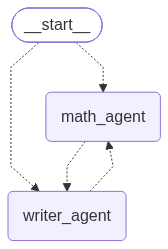

In [59]:
swarm_graph

### Test

**Expected behavior:** The calculation begins with the math agent and can be handed to the writer agent. The final response is stored under one thread ID.

**Model calls:** Variable because agents decide whether to hand off.


In [60]:
def run_swarm():

    print_title(
        "5. SWARM MULTI-AGENT"
    )

    try:

        graph = build_swarm_graph()

    except ImportError:

        print(
            "langgraph-swarm is not installed.\n"
            "Install it using:\n"
            "pip install -U langgraph-swarm"
        )

        return

    config = {
        "configurable": {
            "thread_id":
            "swarm_thread_1"
        }
    }

    result = graph.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": (
                        "Calculate 125 * 32 "
                        "and present the result "
                        "as a professional one-line answer."
                    ),
                }
            ]
        },

        config=config,
    )

    print(
        result["messages"][-1].content
    )

    return result


In [61]:
swarm_result = run_swarm()




5. SWARM MULTI-AGENT
The product of 125 and 32 is 4000.


## 6. Hierarchical Supervisor

**How it works:** A top supervisor selects one team subgraph. The selected team performs specialist work and then rewrites it as a concise report.

**Real-world example:** A company director sends a task to either the research department or the business department instead of managing every employee directly.

```text
Top Supervisor ─┬→ Research Team Subgraph → END
                └→ Business Team Subgraph → END
```


### Build the team subgraphs


In [66]:
class TeamState(TypedDict):

    task: str
    team_output: str

In [67]:
def research_team_node(
    state: TeamState,
):

    research = model.invoke(
        f"""
You are the research specialist.

Research/explain:
{state["task"]}
"""
    )

    writer = model.invoke(
        f"""
You are the research-team writer.

Convert this research into a concise report:

{research.content}
"""
    )

    return {
        "team_output":
        writer.content
    }

In [68]:
def business_team_node(
    state: TeamState,
):

    analysis = model.invoke(
        f"""
You are a business analyst.

Analyze this task from a business perspective:

{state["task"]}
"""
    )

    writer = model.invoke(
        f"""
You are the business-team writer.

Convert this analysis into a concise business report:

{analysis.content}
"""
    )

    return {
        "team_output":
        writer.content
    }


In [69]:
research_team_builder = StateGraph(
    TeamState
)

research_team_builder.add_node(
    "research_team",
    research_team_node,
)

research_team_builder.add_edge(
    START,
    "research_team",
)

research_team_builder.add_edge(
    "research_team",
    END,
)

research_team_graph = (
    research_team_builder.compile()
)

In [70]:
business_team_builder = StateGraph(
    TeamState
)

business_team_builder.add_node(
    "business_team",
    business_team_node,
)

business_team_builder.add_edge(
    START,
    "business_team",
)

business_team_builder.add_edge(
    "business_team",
    END,
)

business_team_graph = (
    business_team_builder.compile()
)

### Top-supervisor state and nodes


In [71]:
class TopSupervisorDecision(BaseModel):

    team: Literal[
        "research_team",
        "business_team",
    ]

In [72]:
top_supervisor_model = (
    model.with_structured_output(
        TopSupervisorDecision
    )
)

In [73]:
class HierarchicalState(TypedDict):

    task: str
    selected_team: str
    final_answer: str

In [74]:
def top_supervisor(
    state: HierarchicalState,
):

    decision = (
        top_supervisor_model.invoke(
            f"""
Choose the best team for this task.

research_team:
Technical research, explanations, educational content.

business_team:
Business analysis, strategy, commercial implications.

Task:
{state["task"]}
"""
        )
    )

    return {
        "selected_team":
        decision.team
    }

In [75]:
def call_research_team(
    state: HierarchicalState,
):

    result = (
        research_team_graph.invoke(
            {
                "task":
                state["task"],

                "team_output":
                "",
            }
        )
    )

    return {
        "final_answer":
        result["team_output"]
    }

In [76]:
def call_business_team(
    state: HierarchicalState,
):

    result = (
        business_team_graph.invoke(
            {
                "task":
                state["task"],

                "team_output":
                "",
            }
        )
    )

    return {
        "final_answer":
        result["team_output"]
    }

In [77]:
def hierarchical_route(
    state: HierarchicalState,
):

    return state["selected_team"]

### Build the parent graph


In [78]:
def build_hierarchical_supervisor():

    builder = StateGraph(
        HierarchicalState
    )

    builder.add_node(
        "top_supervisor",
        top_supervisor,
    )

    builder.add_node(
        "research_team",
        call_research_team,
    )

    builder.add_node(
        "business_team",
        call_business_team,
    )

    builder.add_edge(
        START,
        "top_supervisor",
    )

    builder.add_conditional_edges(
        "top_supervisor",
        hierarchical_route,
        {
            "research_team":
            "research_team",

            "business_team":
            "business_team",
        },
    )

    builder.add_edge(
        "research_team",
        END,
    )

    builder.add_edge(
        "business_team",
        END,
    )

    return builder.compile()


### Generated graph structure

This cell builds the graph and prints its Mermaid definition without invoking the model.


In [79]:
print("RESEARCH TEAM")
show_graph(research_team_graph)

print("BUSINESS TEAM")
show_graph(business_team_graph)

print("TOP-LEVEL GRAPH")
hierarchical_graph = build_hierarchical_supervisor()
show_graph(hierarchical_graph)


RESEARCH TEAM
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	research_team(research_team)
	__end__([<p>__end__</p>]):::last
	__start__ --> research_team;
	research_team --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

BUSINESS TEAM
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	business_team(business_team)
	__end__([<p>__end__</p>]):::last
	__start__ --> business_team;
	business_team --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

TOP-LEVEL GRAPH
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	top_supervisor(top_supervisor)
	research_team(research_team)
	business_team(business_team)
	__end__([<p>__end__</p>]):::last
	__start__ --> top_supervisor;
	top_supervisor -.-> business_team;
	top_supervisor -

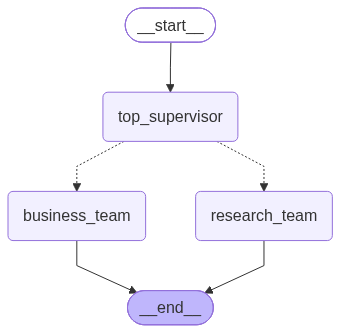

In [80]:
hierarchical_graph

### Test

**Expected behavior:** The enterprise-value question is normally sent to `business_team`, and that team returns a concise report.

**Model calls:** 3: one team-selection call and two calls inside the selected team.


In [81]:
def run_hierarchical_supervisor():

    print_title(
        "6. HIERARCHICAL SUPERVISOR"
    )

    graph = (
        build_hierarchical_supervisor()
    )

    result = graph.invoke(
        {
            "task": (
                "Explain the business value "
                "of using Agentic RAG in an enterprise."
            ),

            "selected_team": "",
            "final_answer": "",
        }
    )

    print(
        "Selected Team:",
        result["selected_team"],
    )

    print(
        "\nFinal Answer:\n",
        result["final_answer"],
    )

    return result


In [82]:
hierarchical_result = run_hierarchical_supervisor()




6. HIERARCHICAL SUPERVISOR
Selected Team: business_team

Final Answer:
 **Business Report: The Value of Agentic RAG in Enterprise Applications**

---

### Introduction

Agentic Retrieval-Augmented Generation (Agentic RAG) integrates advanced AI capabilities by combining Retrieval-Augmented Generation with autonomous agent functions. This fusion enables enterprises to access relevant information dynamically and execute complex, multi-step tasks with minimal human intervention.

---

### Key Business Benefits

1. **Enhanced Decision-Making and Knowledge Access**  
Agentic RAG breaks down data silos by retrieving precise, contextually relevant information from diverse enterprise sources in real-time. This accelerates informed decision-making and reduces time spent on information searches.

2. **Increased Productivity and Operational Efficiency**  
By autonomously managing complex queries and workflows—such as report generation and data summarization—Agentic RAG minimizes manual effort, 

## 7. Parallel Multi-Agent Collaboration with `Send`

**How it works:** A coordinator creates a structured task plan. `Send` starts one specialist worker per task, the reducer collects all outputs, and the aggregator creates the final answer.

**Real-world example:** A financial company asks research, security, and business specialists to evaluate an AI-agent proposal at the same time.

```text
Coordinator → Dynamic Workers → Reducer → Aggregator → END
```


### Plan and state schemas


In [83]:
class AgentTask(BaseModel):

    role: Literal[
        "research",
        "security",
        "business",
    ]

    task: str

In [84]:
class AgentPlan(BaseModel):
    tasks: list[AgentTask]

In [85]:
multi_agent_planner = (
    model.with_structured_output(
        AgentPlan
    )
)

In [86]:
class CollaborationState(TypedDict):
    user_task: str
    tasks: list[AgentTask]
    outputs: Annotated[
        list[str],
        operator.add,
    ]
    final_answer: str

In [87]:
class CollaborationWorkerState(TypedDict):
    role: str
    task: str
    outputs: Annotated[
        list[str],
        operator.add,
    ]

### Coordinator, workers, and aggregator


In [88]:
def collaboration_coordinator(
    state: CollaborationState,
):

    plan = multi_agent_planner.invoke(
        f"""
Break this task into useful specialist tasks.

Available specialist roles:
- research
- security
- business

Only create tasks that are actually useful.

User task:
{state["user_task"]}
"""
    )

    return {
        "tasks":
        plan.tasks
    }

In [89]:
def send_collaboration_workers(
    state: CollaborationState,
):

    return [
        Send(
            "specialist_worker",
            {
                "role":
                item.role,

                "task":
                item.task,
            },
        )

        for item
        in state["tasks"]
    ]


In [90]:
def specialist_worker(
    state: CollaborationWorkerState,
):

    role = state["role"]

    role_prompts = {

        "research":
        "You are a technical research specialist.",

        "security":
        "You are an AI security specialist.",

        "business":
        "You are an enterprise business specialist.",
    }

    response = model.invoke(
        f"""
{role_prompts[role]}

Complete this task:

{state["task"]}
"""
    )

    return {
        "outputs": [
            f"{role.upper()} AGENT:\n"
            f"{response.content}"
        ]
    }

In [91]:
def collaboration_aggregator(
    state: CollaborationState,
):

    all_outputs = "\n\n".join(
        state["outputs"]
    )

    response = model.invoke(
        f"""
You are the final coordinator.

Original task:
{state["user_task"]}

Specialist outputs:
{all_outputs}

Combine them into one coherent final answer.
"""
    )

    return {
        "final_answer":
        response.content
    }

### Build the graph


In [92]:
def build_parallel_collaboration():

    builder = StateGraph(
        CollaborationState
    )

    builder.add_node(
        "coordinator",
        collaboration_coordinator,
    )

    builder.add_node(
        "specialist_worker",
        specialist_worker,
    )

    builder.add_node(
        "aggregator",
        collaboration_aggregator,
    )

    builder.add_edge(
        START,
        "coordinator",
    )

    builder.add_conditional_edges(
        "coordinator",
        send_collaboration_workers,
        [
            "specialist_worker"
        ],
    )

    builder.add_edge(
        "specialist_worker",
        "aggregator",
    )

    builder.add_edge(
        "aggregator",
        END,
    )

    return builder.compile()


### Generated graph structure

This cell builds the graph and prints its Mermaid definition without invoking the model.


In [93]:
collaboration_graph = build_parallel_collaboration()
show_graph(collaboration_graph)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	coordinator(coordinator)
	specialist_worker(specialist_worker)
	aggregator(aggregator)
	__end__([<p>__end__</p>]):::last
	__start__ --> coordinator;
	coordinator -.-> specialist_worker;
	specialist_worker --> aggregator;
	aggregator --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



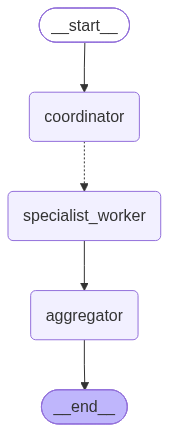

In [94]:
collaboration_graph

### Test

**Expected behavior:** The planner creates useful specialist tasks, workers run dynamically, and one combined enterprise assessment is returned.

**Model calls:** `N + 2`: planner, `N` workers, and aggregator.


In [95]:
def run_parallel_collaboration():

    print_title(
        "7. PARALLEL MULTI-AGENT COLLABORATION WITH Send()"
    )

    graph = (
        build_parallel_collaboration()
    )

    result = graph.invoke(
        {
            "user_task": (
                "Evaluate the use of AI agents "
                "inside a large financial enterprise."
            ),

            "tasks": [],
            "outputs": [],
            "final_answer": "",
        }
    )

    print(
        result["final_answer"]
    )

    return result


In [96]:
collaboration_result = run_parallel_collaboration()




7. PARALLEL MULTI-AGENT COLLABORATION WITH Send()
Certainly! Below is a comprehensive evaluation of the use of AI agents inside a large financial enterprise, integrating insights on technology, business benefits, and security considerations to provide a balanced and actionable overview.

---

# Evaluation of AI Agents in a Large Financial Enterprise

---

## 1. Overview of AI Agent Technologies and Applications

AI agents are autonomous or semi-autonomous software entities that perceive their environment, make decisions, and perform actions to achieve specific goals. In financial enterprises, they leverage advanced AI subfields such as machine learning (ML), natural language processing (NLP), reinforcement learning (RL), and cognitive computing to automate, optimize, and innovate financial processes.

### Key AI Agent Types and Use Cases:

| AI Agent Technology           | Key Technologies                  | Financial Applications                      | Example Use Case              

## 8. Coordinator-Guided Peer Network

**How it works:** Research, analysis, and writing peers share notes. A lightweight coordinator selects the next peer after each step. This is coordinator-guided, not a pure peer-to-peer network. A six-turn limit prevents an endless loop.

**Real-world example:** A round-table facilitator decides whether the researcher, analyst, or writer should speak next until the group has a complete explanation.

```text
Coordinator → Peer → Shared Notes → Coordinator → Next Peer → Finish
```


### Decision and network state


In [97]:
class PeerDecision(BaseModel):

    next_agent: Literal[
        "research_peer",
        "analysis_peer",
        "writer_peer",
        "FINISH",
    ]

    message: str

In [98]:
peer_router = model.with_structured_output(
    PeerDecision
)

In [99]:
class NetworkState(TypedDict):
    task: str
    notes: Annotated[
        list[str],
        operator.add,
    ]
    next_agent: str
    final_answer: str
    network_turns: int

### Peer and coordinator nodes


In [100]:
def network_research_peer(
    state: NetworkState,
):

    previous = "\n\n".join(
        state.get(
            "notes",
            [],
        )
    )

    response = model.invoke(
        f"""
You are the research peer.

Task:
{state["task"]}

Previous peer notes:
{previous}

Add useful research information.
"""
    )

    return {
        "notes": [
            "RESEARCH:\n"
            + response.content
        ]
    }

In [101]:
def network_analysis_peer(
    state: NetworkState,
):

    previous = "\n\n".join(
        state.get(
            "notes",
            [],
        )
    )

    response = model.invoke(
        f"""
You are the analysis peer.

Task:
{state["task"]}

Current team notes:
{previous}

Analyze the information and identify useful conclusions.
"""
    )

    return {
        "notes": [
            "ANALYSIS:\n"
            + response.content
        ]
    }

In [102]:
def network_writer_peer(
    state: NetworkState,
):

    previous = "\n\n".join(
        state.get(
            "notes",
            [],
        )
    )

    response = model.invoke(
        f"""
You are the writing peer.

Task:
{state["task"]}

Current team notes:
{previous}

Create a polished draft.
"""
    )

    return {
        "notes": [
            "WRITER:\n"
            + response.content
        ]
    }

In [103]:
def peer_coordinator(
    state: NetworkState,
):

    network_turns = state.get(
        "network_turns",
        0,
    ) + 1

    notes = "\n\n".join(
        state.get(
            "notes",
            [],
        )
    )

    if network_turns >= 6 and notes:
        return {
            "next_agent": "FINISH",
            "network_turns": network_turns,
        }

    decision = peer_router.invoke(
        f"""
You coordinate a guided peer network.

Task:
{state["task"]}

Current notes:
{notes or "No work completed yet."}

Available peers:
- research_peer
- analysis_peer
- writer_peer
- FINISH

Choose the most useful next peer.
When the task has enough research, analysis,
and a polished answer, choose FINISH.

Return:
- next_agent
- short reason/message
"""
    )

    return {
        "next_agent":
        decision.next_agent,

        "network_turns":
        network_turns,
    }

In [104]:
def network_finish(
    state: NetworkState,
):

    notes = "\n\n".join(
        state["notes"]
    )

    response = model.invoke(
        f"""
Create the final answer.

Original task:
{state["task"]}

Peer-agent work:
{notes}
"""
    )

    return {
        "final_answer":
        response.content
    }

In [105]:
def network_route(
    state: NetworkState,
):

    return state["next_agent"]

### Build the graph


In [106]:
def build_coordinator_guided_network():

    builder = StateGraph(
        NetworkState
    )

    builder.add_node(
        "peer_coordinator",
        peer_coordinator,
    )

    builder.add_node(
        "research_peer",
        network_research_peer,
    )

    builder.add_node(
        "analysis_peer",
        network_analysis_peer,
    )

    builder.add_node(
        "writer_peer",
        network_writer_peer,
    )

    builder.add_node(
        "finish",
        network_finish,
    )

    builder.add_edge(
        START,
        "peer_coordinator",
    )

    builder.add_conditional_edges(
        "peer_coordinator",
        network_route,
        {
            "research_peer":
            "research_peer",

            "analysis_peer":
            "analysis_peer",

            "writer_peer":
            "writer_peer",

            "FINISH":
            "finish",
        },
    )

    builder.add_edge(
        "research_peer",
        "peer_coordinator",
    )

    builder.add_edge(
        "analysis_peer",
        "peer_coordinator",
    )

    builder.add_edge(
        "writer_peer",
        "peer_coordinator",
    )

    builder.add_edge(
        "finish",
        END,
    )

    return builder.compile()


### Generated graph structure

This cell builds the graph and prints its Mermaid definition without invoking the model.


In [107]:
network_graph = build_coordinator_guided_network()
show_graph(network_graph)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	peer_coordinator(peer_coordinator)
	research_peer(research_peer)
	analysis_peer(analysis_peer)
	writer_peer(writer_peer)
	finish(finish)
	__end__([<p>__end__</p>]):::last
	__start__ --> peer_coordinator;
	analysis_peer --> peer_coordinator;
	peer_coordinator -.-> analysis_peer;
	peer_coordinator -. &nbsp;FINISH&nbsp; .-> finish;
	peer_coordinator -.-> research_peer;
	peer_coordinator -.-> writer_peer;
	research_peer --> peer_coordinator;
	writer_peer --> peer_coordinator;
	finish --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



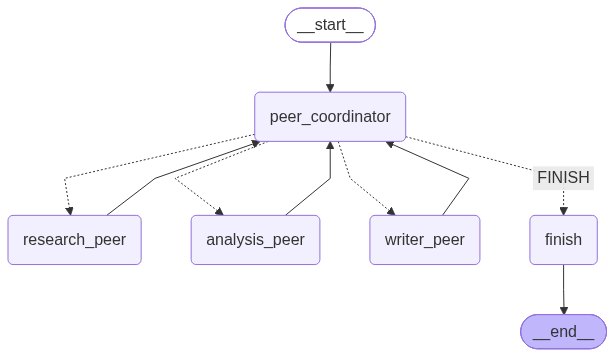

In [108]:
network_graph

### Test

**Expected behavior:** The coordinator selects useful peers, notes accumulate, and the finish node creates the final beginner-friendly explanation.

**Model calls:** Variable and bounded by the network-turn limit.


In [109]:
def run_coordinator_guided_network():

    print_title(
        "8. COORDINATOR-GUIDED PEER NETWORK"
    )

    graph = (
        build_coordinator_guided_network()
    )

    result = graph.invoke(
        {
            "task": (
                "Create a beginner-friendly explanation "
                "of multi-agent AI systems."
            ),

            "notes": [],
            "next_agent": "",
            "final_answer": "",
            "network_turns": 0,
        },

        config={
            "recursion_limit": 20
        },
    )

    print(
        result["final_answer"]
    )

    return result


In [110]:
network_result = run_coordinator_guided_network()




8. COORDINATOR-GUIDED PEER NETWORK
Here is the final beginner-friendly explanation of multi-agent AI systems:

---

## Understanding Multi-Agent AI Systems: A Beginner’s Guide

### What Are Multi-Agent AI Systems?

Imagine a team of robots cleaning a house. One robot vacuums, another dusts, and a third organizes items. They talk to each other and work together to finish the job faster and better. This simple example captures the essence of **multi-agent AI systems**.

A **multi-agent AI system** is made up of multiple intelligent agents—these can be software programs, robots, or virtual characters—that act independently but interact with each other and their surroundings. Each agent has its own goals but can cooperate, compete, or negotiate with others to achieve individual or shared objectives.

---

### Key Ideas to Know

- **Agent:** An independent entity that senses its environment, makes decisions, and takes actions.
- **Environment:** The space or context where agents operate a